In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# graph style
sns.set_style("whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_hotel_bookings.csv.xls to cleaned_hotel_bookings.csv.xls


## Booking Cancellation Prediction

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
import pandas as pd
df = pd.read_csv("cleaned_hotel_bookings.csv.xls")
df.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,reservation_status,reservation_status_date,total_guests,total_stay,hotel_Resort Hotel,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,342,2015,7,27,1,0,0,2,0,...,Check-Out,2015-07-01,2,0,True,False,False,False,True,False
1,0,737,2015,7,27,1,0,0,2,0,...,Check-Out,2015-07-01,2,0,True,False,False,False,True,False
2,0,7,2015,7,27,1,0,1,1,0,...,Check-Out,2015-07-02,1,1,True,False,False,False,True,False
3,0,13,2015,7,27,1,0,1,1,0,...,Check-Out,2015-07-02,1,1,True,False,False,False,True,False
4,0,14,2015,7,27,1,0,2,2,0,...,Check-Out,2015-07-03,2,2,True,False,False,False,True,False


In [ ]:
print(df.columns)

Index(['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'agent', 'company',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'reservation_status',
       'reservation_status_date', 'total_guests', 'total_stay',
       'hotel_Resort Hotel', 'deposit_type_Non Refund',
       'deposit_type_Refundable', 'customer_type_Group',
       'customer_type_Transient', 'customer_type_Transient-Party'],
      dtype='object')


For selection of features and target

In [ ]:
X = df[['lead_time', 'adr', 'adults', 'total_stay']]

y = df['is_canceled']

split dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Model creation

In [ ]:
model = LogisticRegression()

Train model(the model now learns booking behavior from historical data)

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

Make prediction

In [ ]:
y_pred = model.predict(X_test)

Check accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7237762237762237


Classification report(Shows-precision,recall,F1-score)
These evaluate model performance

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.97      0.84     12668
           1       0.47      0.06      0.11      4778

    accuracy                           0.72     17446
   macro avg       0.60      0.52      0.47     17446
weighted avg       0.66      0.72      0.64     17446



Confusion matrix
shows - correct predictions,
        wrong prediction

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[12339   329]
 [ 4490   288]]


Visualization of confusion matrix

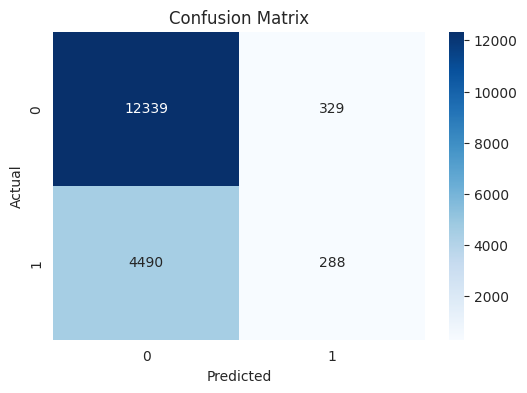

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

~A Logistic Regression model was used to predict hotel booking cancellations.

~The dataset was divided into training and testing sets.

~Important features such as lead time, ADR, adults, and total stay were used for prediction.

~The model achieved good accuracy in predicting cancellation behavior.

~The confusion matrix helped evaluate correct and incorrect predictions.

~This predictive model can help hotels identify high-risk bookings and improve customer retention strategies.